In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
class MLP_MNIST(nn.Module):
  def __init__(self):
    super().__init__()

    self.mlp_stack = nn.Sequential(
        nn.Linear(784,16),
        nn.ReLU(),
        nn.Linear(16,16),
        nn.ReLU(),
        nn.Linear(16,10)
    )

  def forward(self,x):
    x = x.view(x.shape[0],-1)
    return self.mlp_stack(x)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
model = MLP_MNIST().to(device)

cpu


In [10]:
tranform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)),

])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=tranform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=tranform
)

train_loaders = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loaders = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

torch.Size([128, 1, 28, 28])


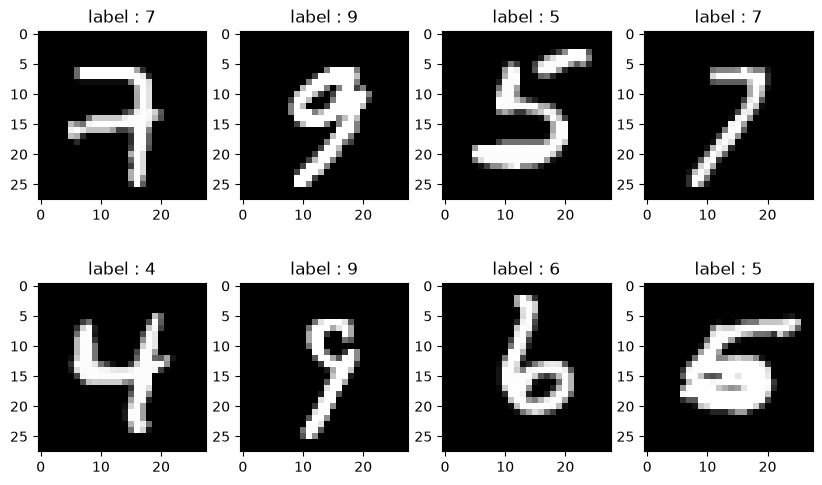

In [5]:
images,lables = next(iter(train_loaders))
print(images.shape)
plt.figure(figsize=(10,6))
for i in range(8):
    image = images[i]
    image = image.permute(1,2,0)
    label = lables[i]
    plt.subplot(2,4,i+1)
    plt.imshow(image,cmap='gray')
    plt.title(f"label : {label}")
    

In [6]:
#Hyper-paramaeters
nums_epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [7]:
def train_loop(model, train_loader, criterion, optimizer):
  model.train()

  running_loss = 0
  correct = 0
  total = 0

  for images,labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    # Prediction
    logits = model(images)

    # Compute the loss
    loss = criterion(logits,labels)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()

    # Weight update
    optimizer.step()

    running_loss += loss.item()

    predictions = torch.argmax(logits,dim = 1)
    correct += (predictions == labels).sum().item()
    total += labels.size(0)

  epoch_loss = running_loss / len(train_loader)
  epoch_acc = correct / total

  print(f"Train Loss : {epoch_loss:.4f} | Train Acc : {epoch_acc:.4f}")


In [8]:
for epoch in range(nums_epochs):
    print(f"Epoch : {epoch+1}")
    train_loop(model,train_loaders,criterion,optimizer)

Epoch : 1
Train Loss : 0.9137 | Train Acc : 0.7150
Epoch : 2
Train Loss : 0.3914 | Train Acc : 0.8883
Epoch : 3
Train Loss : 0.3329 | Train Acc : 0.9046
Epoch : 4
Train Loss : 0.3110 | Train Acc : 0.9110
Epoch : 5
Train Loss : 0.2957 | Train Acc : 0.9140
Epoch : 6
Train Loss : 0.2860 | Train Acc : 0.9173
Epoch : 7
Train Loss : 0.2794 | Train Acc : 0.9189
Epoch : 8
Train Loss : 0.2703 | Train Acc : 0.9207
Epoch : 9
Train Loss : 0.2656 | Train Acc : 0.9228
Epoch : 10
Train Loss : 0.2608 | Train Acc : 0.9234


In [12]:
# Test Acc

def test_loop(model,test_loader):
  model.eval()

  correct = 0
  total = 0

  with torch.no_grad():
    for images,labels in test_loader:

      images = images.to(device)
      labels = labels.to(device)

      logits = model(images)

      predictions = torch.argmax(logits,dim = 1)

      correct += (predictions == labels).sum().item()
      total += labels.size(0)

  epoch_acc = correct / total

  print(f"Test Acc : {epoch_acc:.4f}")

test_loop(model,test_loaders)

Test Acc : 0.9149
